# 03 — Platform-Level Content Strategy Analysis (Part I)

In this notebook, we will analyze **Prime Video** streaming platform at a time and translate charts into a short, insight-driven narrative about that platform’s **content identity**.

**We will**
- Filter content to Prime Video platform
- Visualize platform-specific patterns:
  - Genre mix
  - Release year distribution
  - Movie vs TV focus (from the combined dataset)
- Write a brief summary paragraph supported by evidence 

**Datasets used**
- `MoviesOnStreamingPlatforms_Cleaned.csv`
- `TVShowsOnStreamingPlatforms_Cleaned.csv`


In [22]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


In [23]:
# Load cleaned datasets
DATA_DIR = Path("G:\The US\Gradute School\Build Project\Streaming wars\streaming-bi-template\streaming-bi-template\Data")  # adjust if needed

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

movies = pd.read_csv(MOVIES_PATH)
tv = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head(3)


<>:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\gideo\AppData\Local\Temp\ipykernel_10984\899312847.py:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  DATA_DIR = Path("G:\The US\Gradute School\Build Project\Streaming wars\streaming-bi-template\streaming-bi-template\Data")  # adjust if needed


Movies shape: (9515, 19)
TV shape: (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7,0,david attenborough: a life on our planet


In [24]:
# Load cleaned datasets
DATA_DIR = Path("G:\The US\Gradute School\Build Project\Streaming wars\streaming-bi-template\streaming-bi-template\Data")  # adjust if needed

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

movies = pd.read_csv(MOVIES_PATH)
tv = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head(3)


Movies shape: (9515, 19)
TV shape: (5368, 19)


<>:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\gideo\AppData\Local\Temp\ipykernel_10984\899312847.py:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  DATA_DIR = Path("G:\The US\Gradute School\Build Project\Streaming wars\streaming-bi-template\streaming-bi-template\Data")  # adjust if needed


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7,0,david attenborough: a life on our planet


## Quick schema check

The cleaned datasets share the same schema. Important columns we will use:
- `Title`, `Year`
- Platform indicators: `Netflix`, `Hulu`, `Prime Video`, `Disney+` (1 = available on that platform)
- `Type` (movie vs tv_show)
- `Genre` (comma-separated for movies, sometimes verbose for TV)
- `IMDb`, `RottenTomatoes_Score`, `Age` / `Age_Min`


In [25]:
movies.columns

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre',
       'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key'],
      dtype='str')

In [26]:
# Combine into one content table (movies + tv)
movies2 = movies.copy()
tv2 = tv.copy()

df = pd.concat([movies2, tv2], ignore_index=True)

# Basic sanity checks
df[["Title", "Year", "Type", "Netflix", "Hulu", "Prime Video", "Disney+", "Type"]].head()


,Title,Year,Type,Netflix,Hulu,Prime Video,Disney+,Type
0,The Irishman,2019,movie,1,0,0,0,movie
1,Dangal,2016,movie,1,0,0,0,movie
2,David Attenborough: A Life on Our Planet,2020,movie,1,0,0,0,movie
3,Lagaan: Once Upon a Time in India,2001,movie,1,0,0,0,movie
4,Roma,2018,movie,1,0,0,0,movie


## Reshape to a platform-level view (long format)

Right now, each row has 4 platform indicator columns.  
For platform analysis, it's convenient to convert the dataset into a **long format** where each title appears once per platform it belongs to.


In [27]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

def to_long_platform(df_in: pd.DataFrame) -> pd.DataFrame:
    base_cols = [c for c in df_in.columns if c not in platform_cols]

    # Melt platform indicator columns into rows
    melted = df_in.melt(
        id_vars=base_cols,
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )

    # Keep only records where on_platform == 1
    long_df = melted[melted["on_platform"] == 1].drop(columns=["on_platform"])
    return long_df

df_long = to_long_platform(df)

print("Original rows:", len(df))
print("Long rows (one per platform):", len(df_long))
df_long[["Title", "Year", "Type", "platform", "Genre", "IMDb", "RottenTomatoes_Score"]].head()


Original rows: 14883
Long rows (one per platform): 15551


,Title,Year,Type,platform,Genre,IMDb,RottenTomatoes_Score
0,The Irishman,2019,movie,Netflix,"Biography, Crime, Drama",7.8,98.0
1,Dangal,2016,movie,Netflix,"Action, Biography, Drama",8.3,97.0
2,David Attenborough: A Life on Our Planet,2020,movie,Netflix,"Documentary, Biography",8.9,95.0
3,Lagaan: Once Upon a Time in India,2001,movie,Netflix,"Drama, Musical, Sport",8.1,94.0
4,Roma,2018,movie,Netflix,Drama,7.6,94.0


## Analyzing Prime Video

In [28]:
PLATFORM = "Prime Video" 
platform_df = df_long[df_long["platform"] == PLATFORM].copy()

print("Platform:", PLATFORM)
print("Rows:", platform_df.shape)
platform_df.head(3)

Platform: Prime Video
Rows: (5944, 16)


,ID,Title,Year,Age,Rotten Tomatoes,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key,platform
29882,117,The Terminal,2004,13+,82/100,movie,"Comedy, Drama, Romance",United States,"English, Bulgarian, Spanish, Russian, Mandarin...",7.4,tt0362227,82.0,13,0,the terminal,Prime Video
29921,156,Seven Pounds,2008,13+,80/100,movie,"Drama, Mystery, Thriller",United States,"English, Spanish",7.6,tt0814314,80.0,13,0,seven pounds,Prime Video
29924,159,Les Misérables,2012,13+,80/100,movie,"Drama, Musical, Romance","United Kingdom, United States",English,7.5,tt1707386,80.0,13,0,les misérables,Prime Video


## 1) Movie vs TV focus


In [29]:
type_counts = platform_df["Type"].value_counts()

type_counts

Type
movie      4113
tv_show    1831
Name: count, dtype: int64

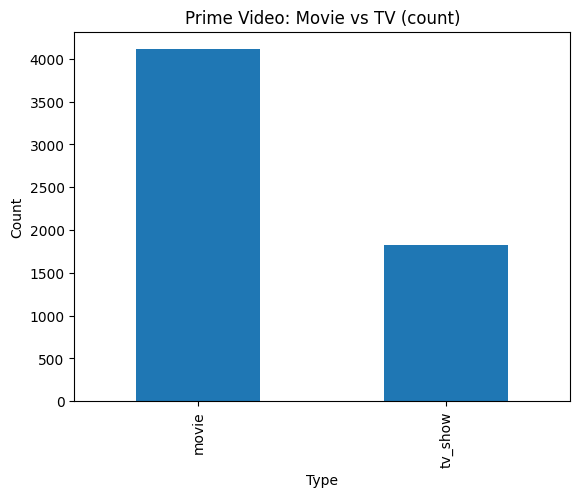

In [30]:
type_counts.plot(kind="bar")
plt.title(f"{PLATFORM}: Movie vs TV (count)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


## 2) Genre mix (Top 10)

Genres are stored in a text field. For movies it's comma-separated; for TV it can be a verbose label.
We'll use a simple approach:
- split by comma (if present)
- trim whitespace
- count genres


In [31]:
def top_genres(df_in: pd.DataFrame, top_n: int = 10) -> pd.Series:
    g = df_in["Genre"].dropna().astype(str)
    # split on comma; if no comma, this still returns a single-item list
    exploded = g.str.split(",").explode().str.strip()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(top_n)

genre_top = top_genres(platform_df, top_n=10)
genre_top

Genre
drama film            2521
reality television    1366
comedy film            347
action film            315
thriller film          219
crime film             211
horror film            209
documentary film       203
romance film           176
comedy drama           165
Name: count, dtype: int64

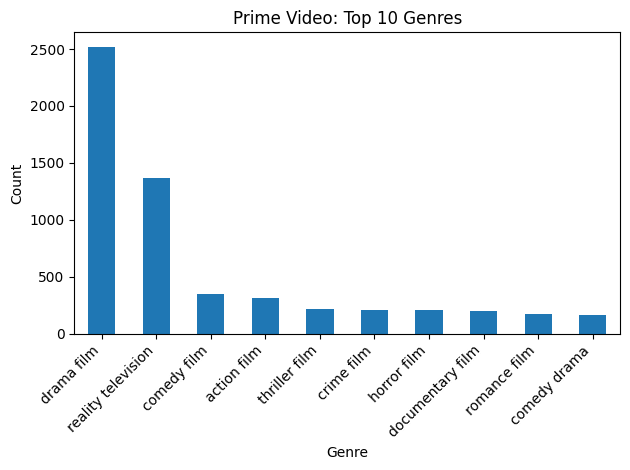

In [32]:
genre_top.plot(kind="bar")
plt.title(f"{PLATFORM}: Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 3) Release year patterns

This answers: is the platform more **new-content-driven** or **catalog/library-heavy**?


In [33]:
# Ensure Year is numeric
platform_df["Year"] = pd.to_numeric(platform_df["Year"], errors="coerce")

platform_df["Year"].describe()

count    5944.000000
mean     2004.450034
std        20.534442
min      1904.000000
25%      2003.000000
50%      2013.000000
75%      2017.000000
max      2021.000000
Name: Year, dtype: float64

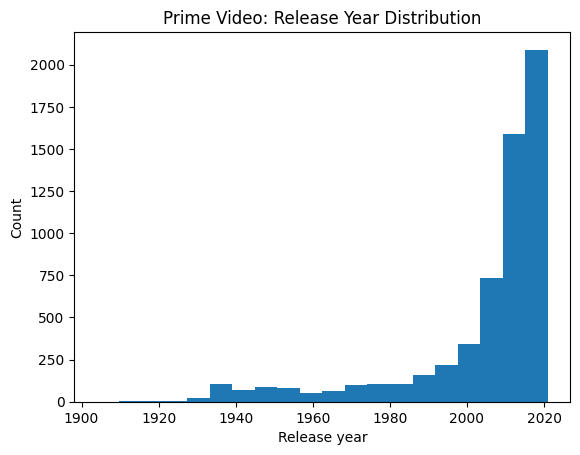

In [34]:
platform_df["Year"].dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Release Year Distribution")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()


## 4) Score distributions (IMDb / Rotten Tomatoes)

These fields may have missing values. Use them as supporting context, not the sole conclusion.


IMDb non-null: 5364


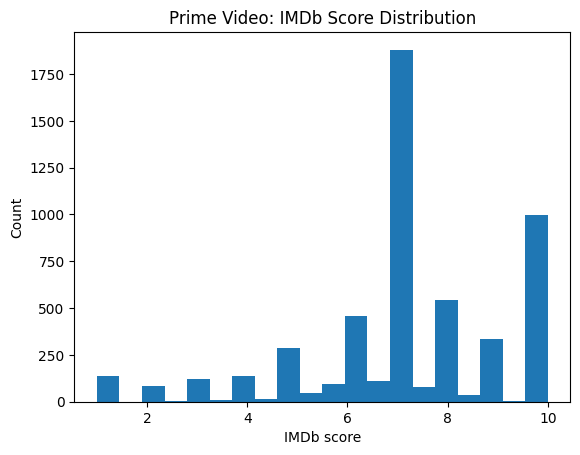

RottenTomatoes_Score non-null: 5944


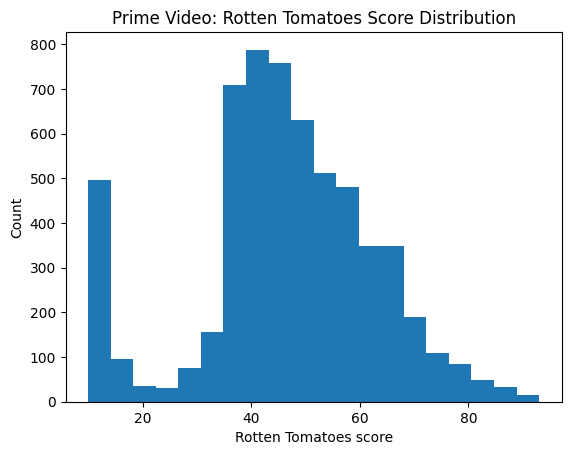

In [35]:
# IMDb distribution
imdb = pd.to_numeric(platform_df["IMDb"], errors="coerce")
print("IMDb non-null:", imdb.notna().sum())

imdb.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: IMDb Score Distribution")
plt.xlabel("IMDb score")
plt.ylabel("Count")
plt.show()

# Rotten Tomatoes distribution
rt = pd.to_numeric(platform_df["RottenTomatoes_Score"], errors="coerce")
print("RottenTomatoes_Score non-null:", rt.notna().sum())

rt.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Rotten Tomatoes Score Distribution")
plt.xlabel("Rotten Tomatoes score")
plt.ylabel("Count")
plt.show()


## 5) Translate charts into a platform “content identity” paragraph


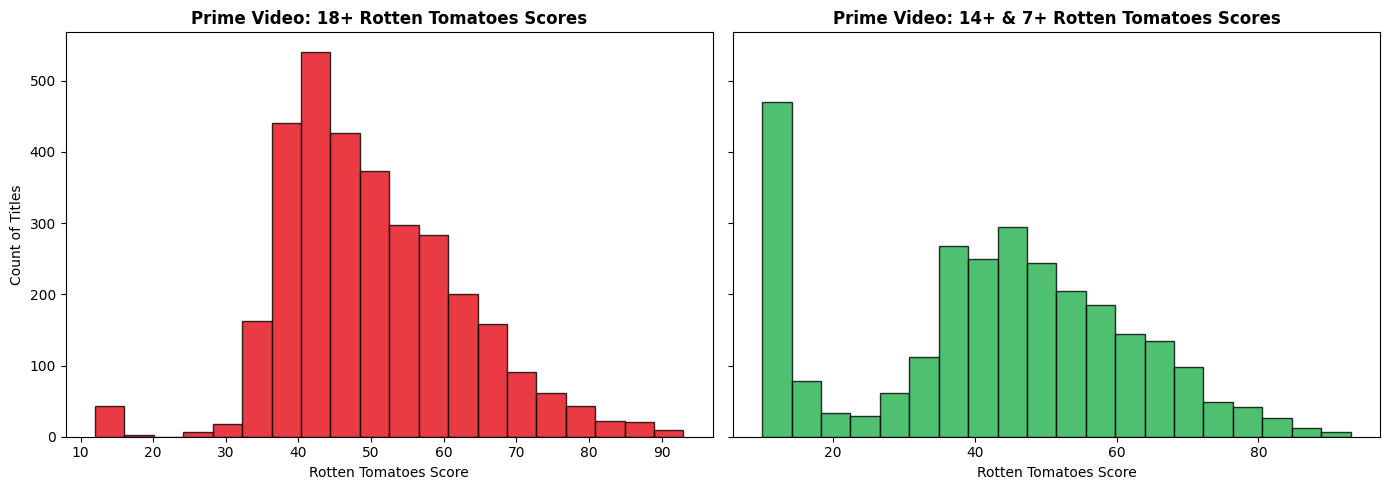

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rt_scores_by_age(platform_name: str):
    sdf = df_long[df_long["platform"] == platform_name].copy()
    
    sdf['rt_score'] = sdf['RottenTomatoes_Score'].astype(str).str.replace('%', '', regex=False)
    sdf['rt_score'] = sdf['rt_score'].str.split('/').str[0]
    sdf['rt_score'] = pd.to_numeric(sdf['rt_score'], errors='coerce')
    
    def group_ages(val):
        val = str(val).strip().upper()
        if val in ['18+', '18', 'TV-MA', 'R', 'NC-17']:
            return '18+'
        elif val in ['13+', '14+', '16+', '7+', 'ALL', 'TV-14', 'PG-13', 'TV-PG', 'PG', 'TV-Y7', 'G']:
            return '14+ and 7+'
        else:
            return 'Unknown'
            
    sdf['age_bucket'] = sdf['Age'].apply(group_ages)
    
    group_18_plus = sdf[sdf['age_bucket'] == '18+']['rt_score'].dropna()
    group_under_18 = sdf[sdf['age_bucket'] == '14+ and 7+']['rt_score'].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    axes[0].hist(group_18_plus, bins=20, color='#e50914', edgecolor='black', alpha=0.8)
    axes[0].set_title(f"{platform_name}: 18+ Rotten Tomatoes Scores", fontweight='bold')
    axes[0].set_xlabel("Rotten Tomatoes Score")
    axes[0].set_ylabel("Count of Titles")
    
    axes[1].hist(group_under_18, bins=20, color='#22b14c', edgecolor='black', alpha=0.8)
    axes[1].set_title(f"{platform_name}: 14+ & 7+ Rotten Tomatoes Scores", fontweight='bold')
    axes[1].set_xlabel("Rotten Tomatoes Score")
    
    plt.tight_layout()
    plt.show()

plot_rt_scores_by_age("Prime Video")

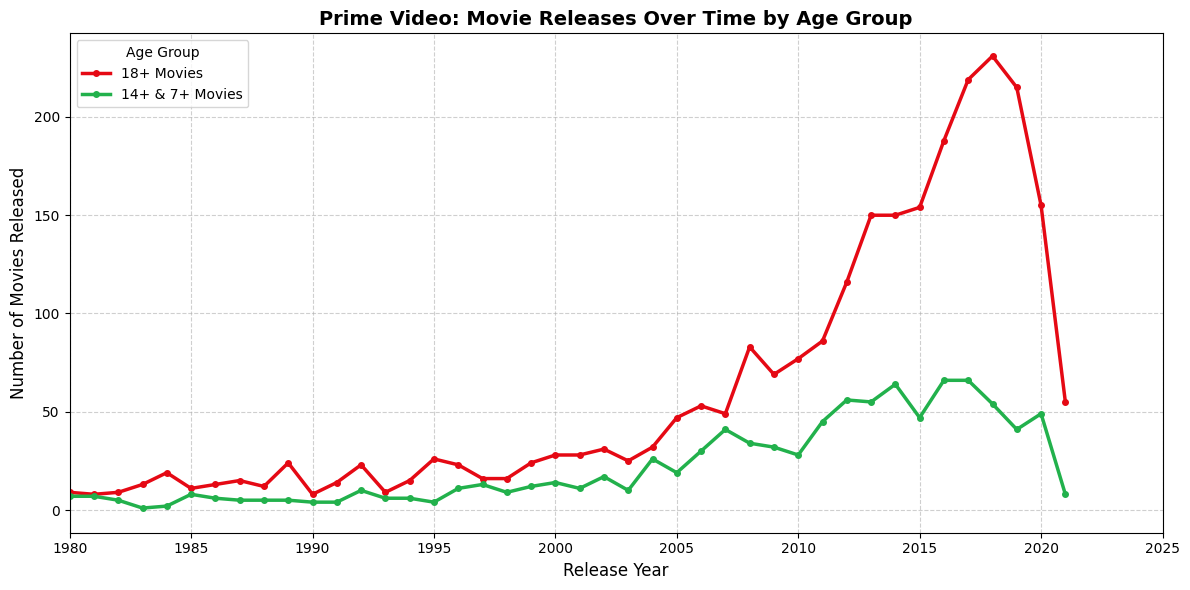

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_age_trends_over_years(platform_name: str):
    sdf = df_long[(df_long["platform"] == platform_name) & (df_long["Type"] == "movie")].copy()
    
    sdf['Year'] = pd.to_numeric(sdf['Year'], errors='coerce')
    sdf = sdf.dropna(subset=['Year'])
    
    def group_ages(val):
        val = str(val).strip().lower()
        if val == '18+':
            return '18+'
        elif val in ['13+', '16+', '7+', 'all']:
            return '14+ and 7+'
        else:
            return 'Unknown'
            
    sdf['age_bucket'] = sdf['Age'].apply(group_ages)
    
    sdf = sdf[sdf['age_bucket'].isin(['18+', '14+ and 7+'])]
    
    yearly_counts = pd.crosstab(sdf['Year'], sdf['age_bucket'])
    
    plt.figure(figsize=(12, 6))
    
    if '18+' in yearly_counts.columns:
        plt.plot(yearly_counts.index, yearly_counts['18+'], 
                 color='#e50914', label='18+ Movies', linewidth=2.5, marker='o', markersize=4)
                 
    if '14+ and 7+' in yearly_counts.columns:
        plt.plot(yearly_counts.index, yearly_counts['14+ and 7+'], 
                 color='#22b14c', label='14+ & 7+ Movies', linewidth=2.5, marker='o', markersize=4)
        
    plt.title(f"{platform_name}: Movie Releases Over Time by Age Group", fontweight='bold', fontsize=14)
    plt.xlabel("Release Year", fontsize=12)
    plt.ylabel("Number of Movies Released", fontsize=12)
    
    plt.xlim(1980, 2025) 
    
    plt.legend(title="Age Group")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_age_trends_over_years("Prime Video")

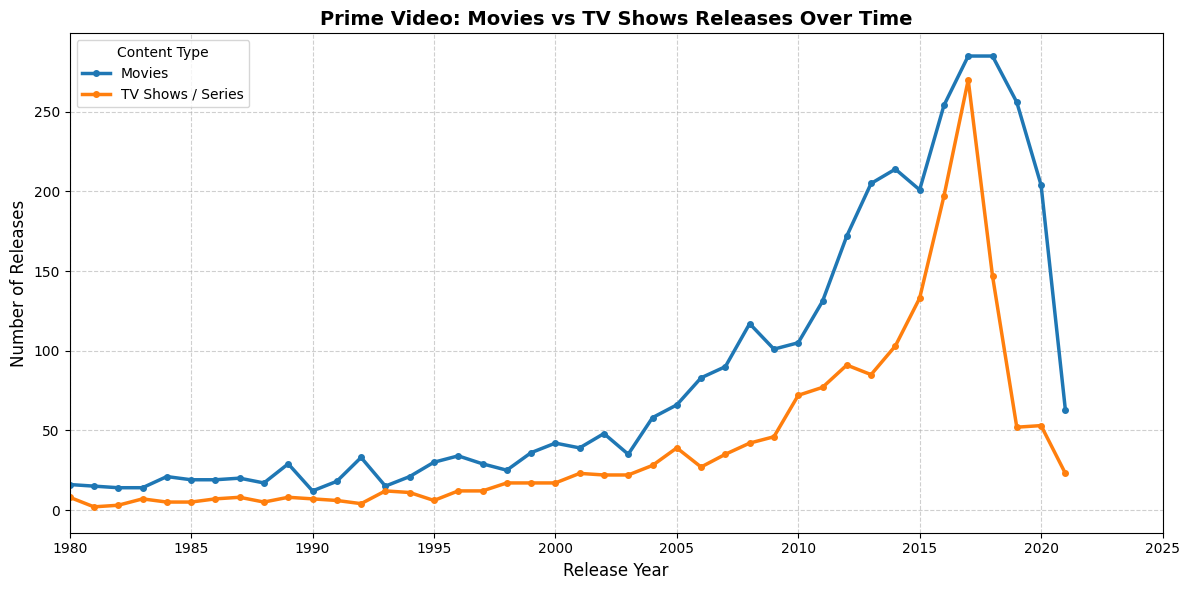

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_type_trends_over_years(platform_name: str):
    sdf = df_long[df_long["platform"] == platform_name].copy()
    
    sdf['Year'] = pd.to_numeric(sdf['Year'], errors='coerce')
    sdf = sdf.dropna(subset=['Year', 'Type'])
    
    sdf['Type'] = sdf['Type'].astype(str).str.strip().str.lower()
    
    yearly_counts = pd.crosstab(sdf['Year'], sdf['Type'])
    
    plt.figure(figsize=(12, 6))
    
    if 'movie' in yearly_counts.columns:
        plt.plot(yearly_counts.index, yearly_counts['movie'], 
                 color='#1f77b4', label='Movies', linewidth=2.5, marker='o', markersize=4)
                 
    if 'tv_show' in yearly_counts.columns:
        plt.plot(yearly_counts.index, yearly_counts['tv_show'], 
                 color='#ff7f0e', label='TV Shows / Series', linewidth=2.5, marker='o', markersize=4)
        
    plt.title(f"{platform_name}: Movies vs TV Shows Releases Over Time", fontweight='bold', fontsize=14)
    plt.xlabel("Release Year", fontsize=12)
    plt.ylabel("Number of Releases", fontsize=12)
    
    plt.xlim(1980, 2025) 
    
    plt.legend(title="Content Type")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_type_trends_over_years("Prime Video")

## Claim:
1) Prime Video is a high-volume, broad-market platform that prioritizes a massive library of movies and mature content (18+),focusing overall quantity and recent growth over quality content.

## Evidence:
1) Format & Volume Bias: The platform holds significantly more movies (>4,000) than TV shows (~1,800). Both formats experienced massive growth driven by recent releases post-2010

2) Mature & Broad Genre Appeal: "Drama film" and "Reality television" absolutely dominate the catalog, than other categories. Timeline data shows a pivot around 2005 where 18+ mature movie releases skyrocketed, completely overpowering 14+ and 7+ family-friendly content.

3) Cost-Efficient Cataloging (Volume over Curation): While they have a huge spike in modern titles, they also maintain a long and steady tail of older legacy films stretching all the way back to the 1920s. When you look at the quality, the bulk of their catalog sits right in that middle-of-the-road 40-50% Rotten Tomatoes range. This pattern indicates a cost-efficient library strategy meant to bulk up the platform's variety rather than focusing strictly on high-rated, prestige storytelling.(Also it is to note that most 14+ and 7+ movies have very low Rotten tomato rating(under 10))

## Weakness:
1) Prime Video has the lowest median Rotten Tomatoes score (~47) among its peer

2) A roughly 2:1 ratio of movies to TV shows may make week-to-week subscriber retention difficult

## Threat:
1) Competitors with higher average critical acclaim (like Hulu and Disney+) threaten to pull away viewers who prefer curated, high-quality viewing over endless scrolling
